### Inputs

In [1]:
#  Inputs
line_label = 'NeVIII' #'NeVIII', 'SiII', 'CIV', or 'cold_line'

eit_wavelength = 195 #171, 195, 284, or 304 [Angstrom]
eit_time = 'late' #'early' or 'late' (early: around 1 or 4 am; late: around 6 or 7 am)

# Threshold value: label (type) and range of percentageRange percentage of the threshold value
threshold_value_type = 'mean' #'max', 'min', 'mean', 'median'
range_percentage = [0., 60.]

# Wavelength ranges to crop spectra
wavelength_range_to_average = [1531.1147, 1551.7688]
wavelength_range_to_analyze_NeVIII = [1540.2, 1541.4]

# save average profile as .npy?
save_average_profile_map = 'yes' 


### Import packages, libraries, data...

In [2]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import datetime as dt
from astropy.io import fits
import matplotlib.patches as patches
from scipy.odr import Model, RealData, ODR
from scipy.interpolate import interp1d
import matplotlib.lines as mlines
import sunpy.map
from astropy.coordinates import SkyCoord
from sunpy.coordinates import frames
import astropy.units as u


import sys
import os
sys.path.append(os.path.abspath('..'))
from auxiliar_functions.data_path import path_data_soho 
from auxiliar_functions.SOHO_aux_functions import *
from auxiliar_functions.calibration_parameters__output import *
from auxiliar_functions.spectroheliogram_functions import *
from auxiliar_functions.solar_rotation_variables import *
from auxiliar_functions.aux_functions import *
from auxiliar_functions.general_variables import *
from auxiliar_functions.NeVIII_rest_wavelength import *


/tmp/ipykernel_377729/1002911172.py:8: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  from scipy.odr import Model, RealData, ODR
/home/mario/anaconda3/envs/phd/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
## Rest wavelength used
rest_wavelength_label = 'Peter_and_Judge_1999' #'SUMER_atlas', 'Peter_1998', 'Dammasch_1999', 'Peter_and_Judge_1999', 'Kelly_database'
lam_0 = 2.*NeVIII_theoretical_wavelength_dic[rest_wavelength_label][0] #Angstrom
lam_unc_0 = 2.*NeVIII_theoretical_wavelength_dic[rest_wavelength_label][1] #Angstrom
print('Rest wavelength Ne VIII (2nd order):', lam_0, r'$\pm$', lam_unc_0, '\u212B')

Rest wavelength Ne VIII (2nd order): 1540.856 $\pm$ 0.014 Å


In [4]:
# Load the intensity map and uncertainties
intensitymap_loaded_dic = np.load('intensity_map_'+line_label+'_interpolated.npz')
intensity_map = intensitymap_loaded_dic['intensity_map'] #2D-array
intensity_map_unc = intensitymap_loaded_dic['intensity_map_unc'] #2D-array
line_center_label = intensitymap_loaded_dic['line_center_label'] 
vmin_sumer, vmax_sumer = intensitymap_loaded_dic['vmin_vmax'] 

# Crop array in latitude 
intensity_map_croplat = intensity_map[slit_top_px:slit_bottom_px+1,:]
intensity_map_unc_croplat = intensity_map_unc[slit_top_px:slit_bottom_px+1,:]


In [5]:
# Import SUMER data interpolated (wavelength calibrated)
data_interpolated_loaded = np.load('../auxiliar_functions/wcal4__spectral_image_list_intepolated_and_wavelength.npz', allow_pickle=True)
spectral_image_interpolated_list = data_interpolated_loaded['spectral_image_interpolated_list']
spectral_image_unc_interpolated_list = data_interpolated_loaded['spectral_image_unc_interpolated_list']
lam_sumer = data_interpolated_loaded['reference_wavelength']          # scalar (0‑d array; use a_loaded.item() for Python float)
lam_sumer_unc = data_interpolated_loaded['unc_reference_wavelength'] #uncertainty of lam_sumer
row_reference = int(data_interpolated_loaded['row_reference'])        # becomes a NumPy array or object array, so I conver it to integer again


Observatory,Solar and Heliospheric Observatory (SOHO)
Instrument,Extreme-ultraviolet Imaging Telescope (EIT)
Detector,EIT
Measurement,195.0 Angstrom
Wavelength,195.0 Angstrom
Observation Date,1999-11-07 06:36:24
Exposure Time,4.597 s
Dimension,[512. 512.] pix
Coordinate System,helioprojective
Scale,[5.254 5.254] arcsec / pix
Reference Pixel,[255.5 255.5] pix

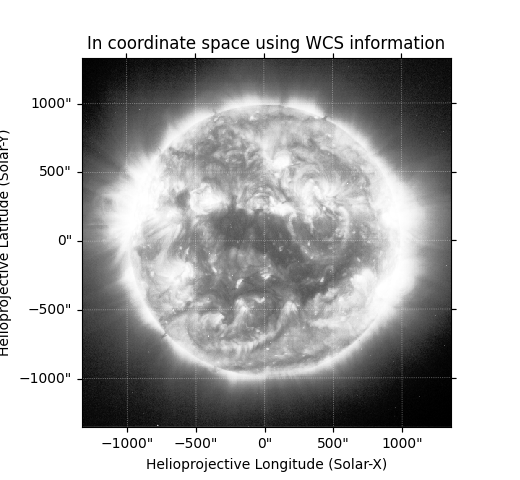
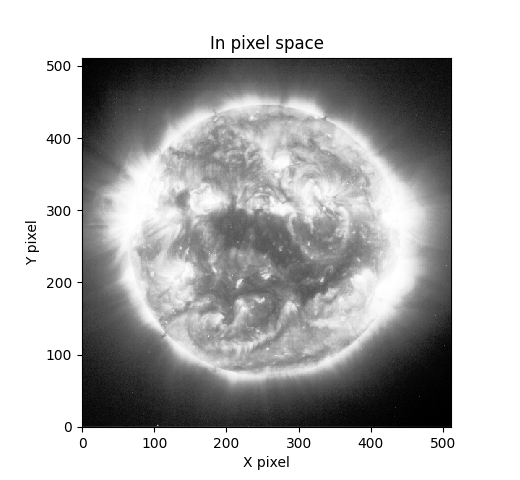
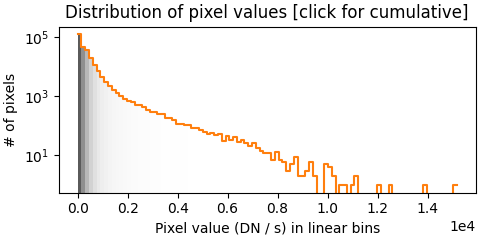
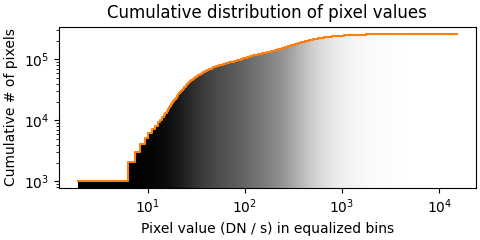

In [6]:
# Import EIT data

# Select the name of the EIT file according to the above inputs
if eit_time=='early':
    if eit_wavelength==171: filename_eit = 'SOHO_EIT_171_19991107T010032_L1.fits'
    elif eit_wavelength==195: filename_eit = 'SOHO_EIT_195_19991107T042103_L1.fits'
    elif eit_wavelength==284: filename_eit = 'SOHO_EIT_284_19991107T011231_L1.fits'
    elif eit_wavelength==304: filename_eit = 'SOHO_EIT_304_19991107T013601_L1.fits'

elif eit_time=='late':
    if eit_wavelength==171: filename_eit = 'SOHO_EIT_171_19991107T070017_L1.fits'
    elif eit_wavelength==195: filename_eit = 'SOHO_EIT_195_19991107T063706_L1.fits'
    elif eit_wavelength==284: filename_eit = 'SOHO_EIT_284_19991107T070704_L1.fits'
    elif eit_wavelength==304: filename_eit = 'SOHO_EIT_304_19991107T073030_L1.fits'

# Path of EIT file
filepath_eit = path_data_soho + 'eit/' + filename_eit

# Extract data and header
data_eit = fits.getdata(filepath_eit)[::-1]
header_eit = fits.getheader(filepath_eit)

# Creating a SunPy map object from an image
map_eit = sunpy.map.Map(filepath_eit)
map_eit

### Compensate solar rotation in SUMER intensity map

In [7]:
from auxiliar_functions.solar_rotation_variables import *
closest_index = closest_index_EIT_SUMER_dic[filename_eit]
closest_time_sumer = closest_time_SUMER_to_EIT_dic[filename_eit]
time_eit = time_EIT_dic[filename_eit]
hour_eit = hour_EIT_dic[filename_eit]
HPlon_rotcomp = HPlon_rotcomp_dic[filename_eit]
HPlon
HPlat
HPlat_croplat = HPlat[slit_top_px:slit_bottom_px+1]

print("Time of EIT image:.......................", time_eit)
print("Closest time of the SUMER raster:........", closest_time_sumer)
print("Index of that SUMER file in the list:....", closest_index)


Time of EIT image:....................... 1999-11-07 06:36:26.946000
Closest time of the SUMER raster:........ 1999-11-07 06:37:32.597000
Index of that SUMER file in the list:.... 155


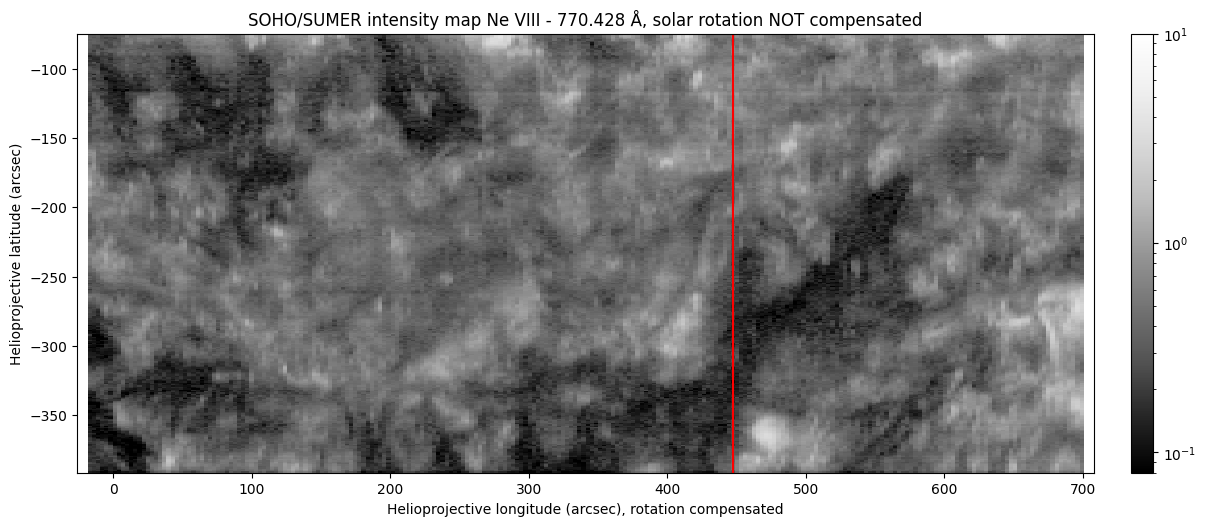

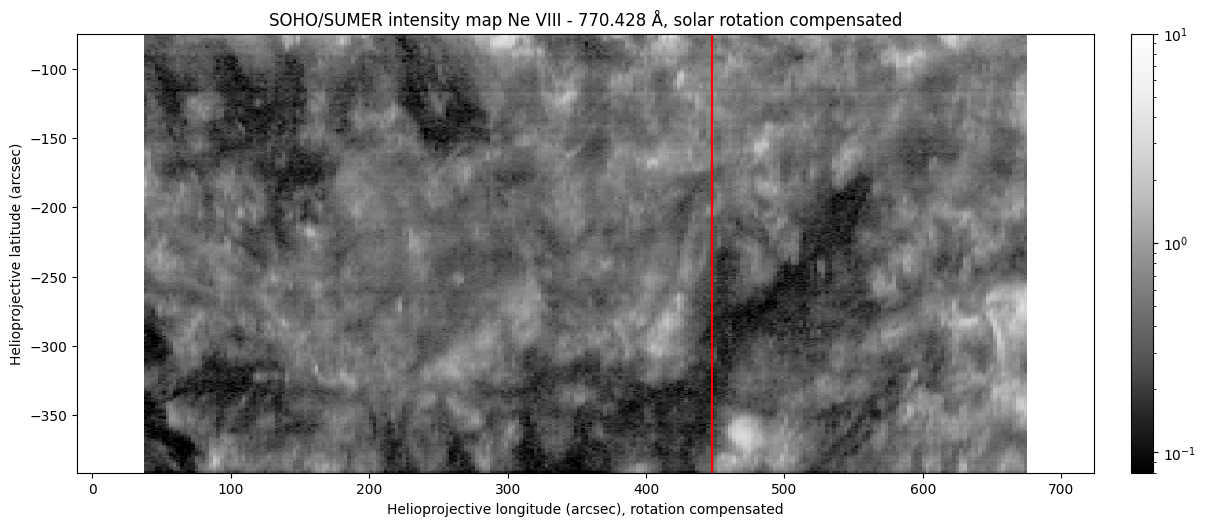

In [8]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 5.7))
img = ax.pcolormesh(HPlon, HPlat_croplat, intensity_map_croplat, cmap='Greys_r', norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer))
cbar = fig.colorbar(img, ax=ax, pad=0.03)
ax.set_title(f'SOHO/SUMER intensity map {line_center_label}, solar rotation NOT compensated')
ax.set_xlabel('Helioprojective longitude (arcsec), rotation compensated')
ax.set_ylabel('Helioprojective latitude (arcsec)')
ax.axvline(x=HPlon[closest_index], linestyle='-', color='red', label='Slit position during\n EIT image')
ax.axis('equal') # Ensures equal scaling of axis x and y
plt.show(block=False)


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 5.7))
img = ax.pcolormesh(HPlon_rotcomp, HPlat_croplat, intensity_map_croplat, cmap='Greys_r', norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer))
cbar = fig.colorbar(img, ax=ax, pad=0.03)
ax.set_title(f'SOHO/SUMER intensity map {line_center_label}, solar rotation compensated')
ax.set_xlabel('Helioprojective longitude (arcsec), rotation compensated')
ax.set_ylabel('Helioprojective latitude (arcsec)')
ax.axvline(x=HPlon_rotcomp[closest_index], linestyle='-', color='red', label='Slit position during\n EIT image')
ax.axis('equal') # Ensures equal scaling of axis x and y
plt.show(block=False)

### Compare SUMER intensity map and EIT

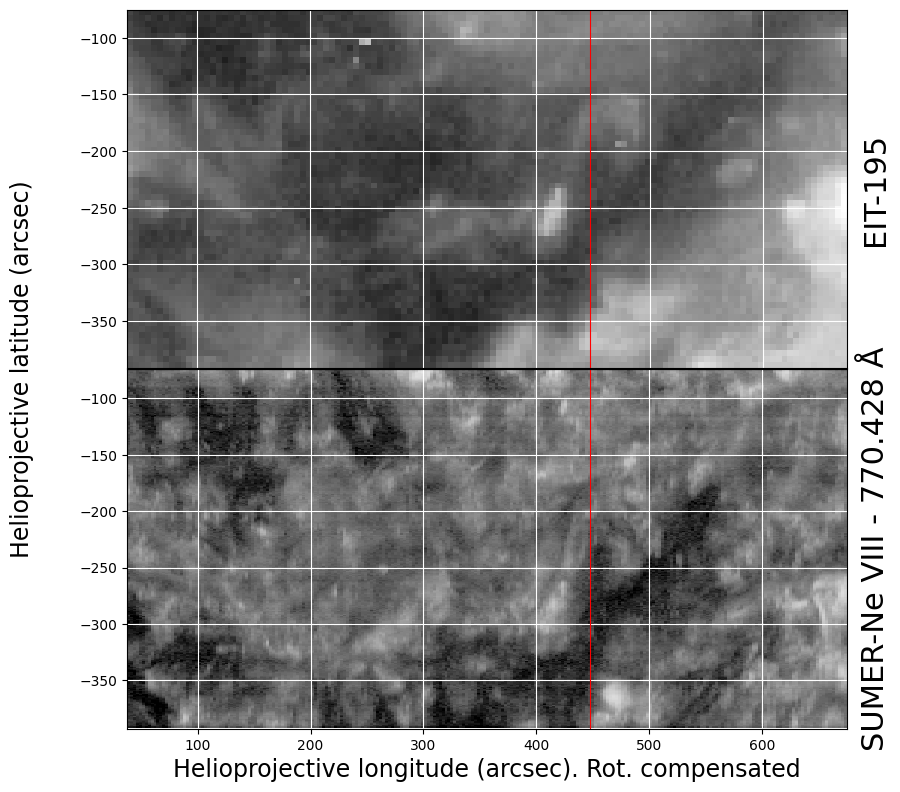

In [9]:
# HP latitude of the top and bottom limits of the SUMER spectra
HPlat_crop_top = HPlat[slit_top_px]
HPlat_crop_bottom = HPlat[slit_bottom_px]


## Find row index in EIT corresponding to these limits
y_px_crop_top = int(np.round(Y__HP_to_pixel(y_HP=HPlat_crop_top, header_eit=header_eit)))
y_px_crop_bottom = int(np.round(Y__HP_to_pixel(y_HP=HPlat_crop_bottom, header_eit=header_eit)))
x_px_crop_left = int(np.round(X__HP_to_pixel(x_HP=HPlon_rotcomp[0], header_eit=header_eit)))
x_px_crop_right = int(np.round(X__HP_to_pixel(x_HP=HPlon_rotcomp[-1], header_eit=header_eit)))


## Crop EIT array
data_eit_crop = data_eit[y_px_crop_top:y_px_crop_bottom, x_px_crop_left:x_px_crop_right]

eit_extent = sumer_extent = [HPlon_rotcomp[0], HPlon_rotcomp[-1], HPlat_croplat[-1], HPlat_croplat[0]]

vmin_eit, vmax_eit = 4e1, 3e3

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(9,8))
label_size = 18
ax[0].imshow(data_eit_crop, norm=LogNorm(vmin=vmin_eit, vmax=vmax_eit), cmap='Greys_r', extent=eit_extent)
ax[1].pcolormesh(HPlon_rotcomp, HPlat_croplat, intensity_map_croplat, cmap='Greys_r', norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer))
ax[1].axis('equal') # Ensures equal scaling of axis x and y
#ax[1].set_title(f'SUMER', fontsize=22)
#ax[0].set_title(f'EIT-{header_eit["WAVELNTH"]}', fontsize=22)
ax[1].set_xlabel('Helioprojective longitude (arcsec). Rot. compensated', fontsize=17)
fig.supylabel('Helioprojective latitude (arcsec)', fontsize=17)
ax[0].text(1.02, 0.5, f'EIT-{header_eit["WAVELNTH"]}', fontsize=22,transform=ax[0].transAxes, va='center', ha='left', rotation=90)
ax[1].text(1.02, 0.5, f'SUMER-{line_center_label}', fontsize=22,transform=ax[1].transAxes, va='center', ha='left', rotation=90)
plt.subplots_adjust(left=0.15, right=0.95, bottom=0.05, top=0.95, wspace=0, hspace=0)
ax[0].grid(color='white')
ax[1].grid(color='white')
ax[0].axvline(x=HPlon_rotcomp[closest_index], linestyle='-', linewidth=0.8, color='red', label='Slit position during\n EIT image')
ax[1].axvline(x=HPlon_rotcomp[closest_index], linestyle='-', linewidth=0.8, color='red', label='Slit position during\n EIT image')
#ax[0].set_xlim([HPlon_rotcomp[0], HPlon_rotcomp[-1]])
#ax[1].set_xlim([HPlon_rotcomp[0], HPlon_rotcomp[-1]])
plt.show(block=False)

### Improve alignment between SUMER intensity map and EIT

In [10]:
# Crop EIT array
data_eit_crop = data_eit[y_px_crop_top:y_px_crop_bottom, x_px_crop_left:x_px_crop_right]

# Corrected alignment
dx_px = 0
dy_px = -6
data_eit_crop_corrected = data_eit[y_px_crop_top+dy_px : y_px_crop_bottom+dy_px, x_px_crop_left+dx_px : x_px_crop_right+dx_px]


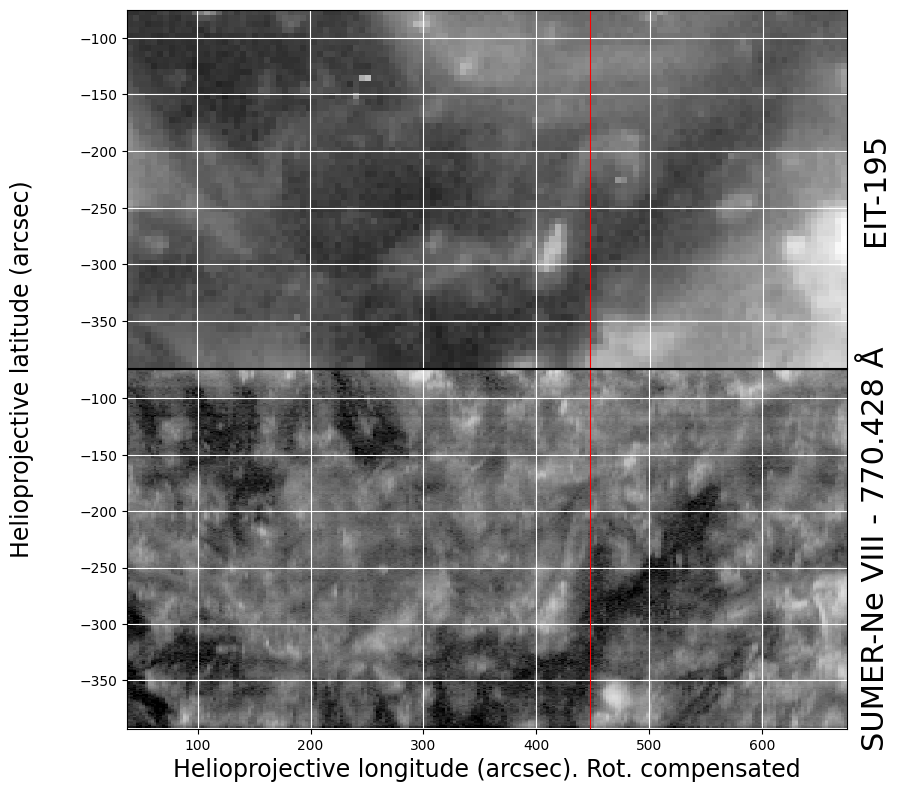

In [11]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(9,8))
label_size = 18
ax[0].imshow(data_eit_crop_corrected, norm=LogNorm(vmin=vmin_eit, vmax=vmax_eit), cmap='Greys_r', extent=eit_extent)
ax[1].pcolormesh(HPlon_rotcomp, HPlat_croplat, intensity_map_croplat, cmap='Greys_r', norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer))
ax[1].axis('equal') # Ensures equal scaling of axis x and y
#ax[1].set_title(f'SUMER', fontsize=22)
#ax[0].set_title(f'EIT-{header_eit["WAVELNTH"]}', fontsize=22)
ax[1].set_xlabel('Helioprojective longitude (arcsec). Rot. compensated', fontsize=17)
fig.supylabel('Helioprojective latitude (arcsec)', fontsize=17)
ax[0].text(1.02, 0.5, f'EIT-{header_eit["WAVELNTH"]}', fontsize=22,transform=ax[0].transAxes, va='center', ha='left', rotation=90)
ax[1].text(1.02, 0.5, f'SUMER-{line_center_label}', fontsize=22,transform=ax[1].transAxes, va='center', ha='left', rotation=90)
plt.subplots_adjust(left=0.15, right=0.95, bottom=0.05, top=0.95, wspace=0, hspace=0)
ax[0].grid(color='white')
ax[1].grid(color='white')
ax[0].axvline(x=HPlon_rotcomp[closest_index], linestyle='-', linewidth=0.8, color='red', label='Slit position during\n EIT image')
ax[1].axvline(x=HPlon_rotcomp[closest_index], linestyle='-', linewidth=0.8, color='red', label='Slit position during\n EIT image')
#ax[0].set_xlim([HPlon_rotcomp[0], HPlon_rotcomp[-1]])
#ax[1].set_xlim([HPlon_rotcomp[0], HPlon_rotcomp[-1]])
plt.show(block=False)

### Link 1 pixel address of EIT to SUMER intensity map

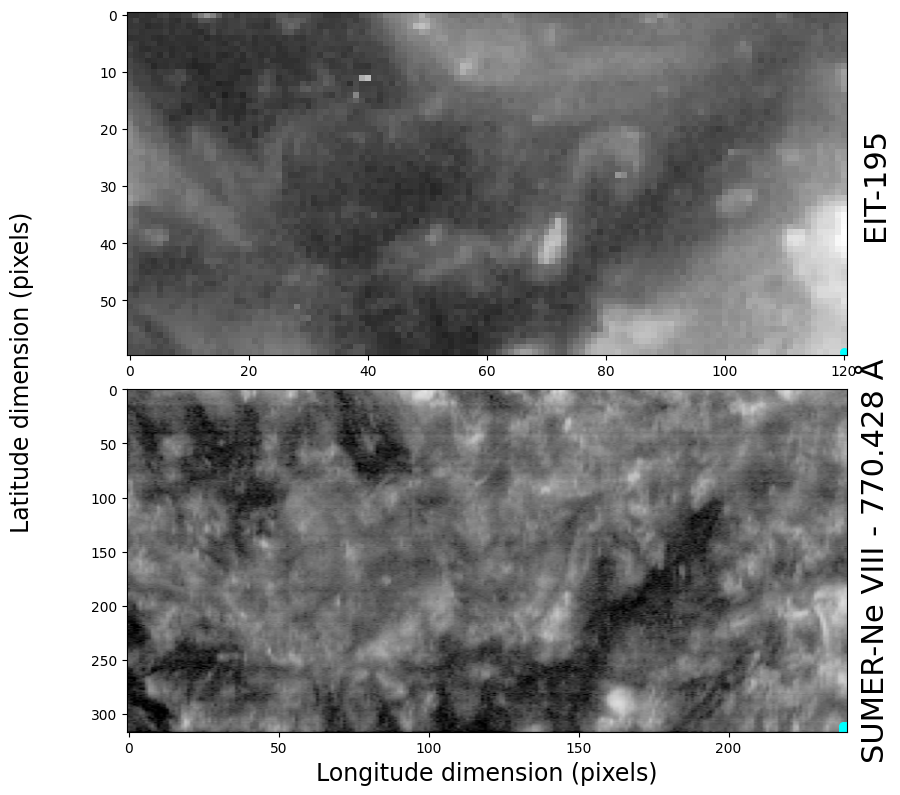

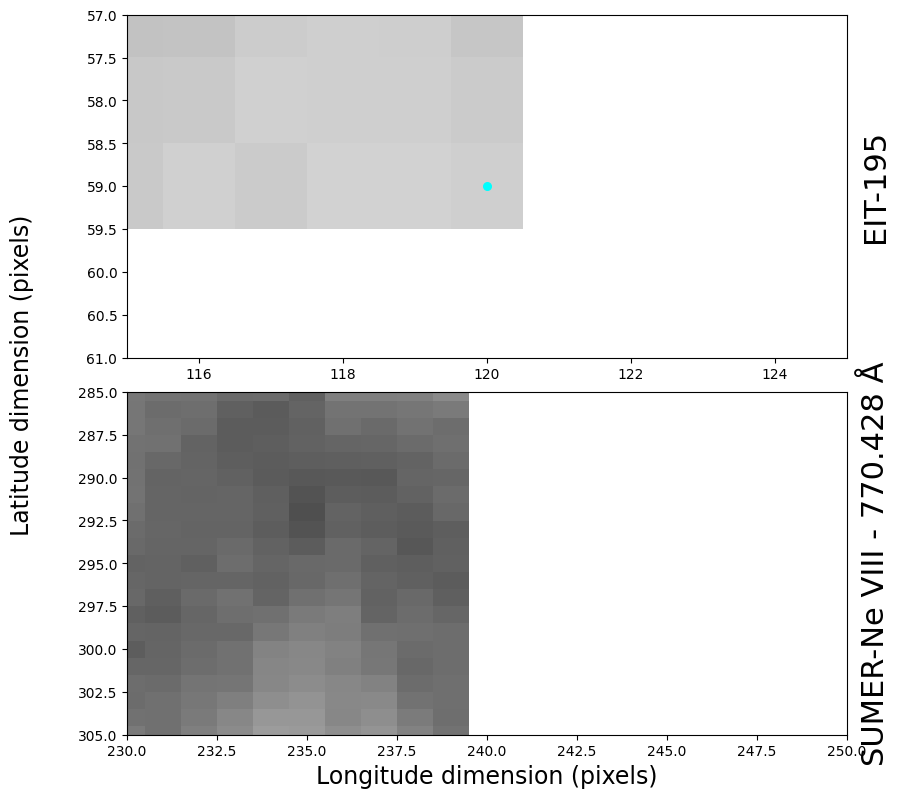

In [17]:
y_row1, x_col1 = 0, 0
y_row1, x_col1 = 1, 1
y_row1, x_col1 = 59, 120
rows_cols_delta_2 = map_pixels_array1_to_array2(arr1=data_eit_crop_corrected, arr2=intensity_map_croplat, pixel_address_list_1=[[y_row1, x_col1]])

# Define extents properly for EACH image
extent_eit_px = [-0.5, data_eit_crop_corrected.shape[1]-0.5, data_eit_crop_corrected.shape[0]-0.5, -0.5]
extent_sumer_px = [-0.5, intensity_map_croplat.shape[1]-0.5, intensity_map_croplat.shape[0]-0.5, -0.5]

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(9,8))
label_size = 18
ax[0].imshow(data_eit_crop_corrected, norm=LogNorm(vmin=vmin_eit, vmax=vmax_eit), cmap='Greys_r', aspect='auto', extent=extent_eit_px)
ax[1].imshow(intensity_map_croplat, norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer), cmap='Greys_r', aspect='auto', extent=extent_sumer_px)
ax[1].set_aspect('auto')

ax[1].set_xlabel('Longitude dimension (pixels)', fontsize=17)
fig.supylabel('Latitude dimension (pixels)', fontsize=17)
ax[0].text(1.02, 0.5, f'EIT-{header_eit["WAVELNTH"]}', fontsize=22,transform=ax[0].transAxes, va='center', ha='left', rotation=90)
ax[1].text(1.02, 0.5, f'SUMER-{line_center_label}', fontsize=22,transform=ax[1].transAxes, va='center', ha='left', rotation=90)
plt.subplots_adjust(left=0.15, right=0.95, bottom=0.05, top=0.95, wspace=0, hspace=0.1)

ax[0].scatter(x_col1, y_row1, color='cyan', s=30)
for y_row2d, x_col2d in rows_cols_delta_2:
    ax[1].scatter(x_col2d, y_row2d, color='cyan', s=30)
plt.show(block=False)




fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(9,8))
label_size = 18
ax[0].imshow(data_eit_crop_corrected, norm=LogNorm(vmin=vmin_eit, vmax=vmax_eit), cmap='Greys_r', aspect='auto', extent=extent_eit_px)
ax[1].imshow(intensity_map_croplat, norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer), cmap='Greys_r', aspect='auto', extent=extent_sumer_px)
ax[1].set_aspect('auto')

ax[1].set_xlabel('Longitude dimension (pixels)', fontsize=17)
fig.supylabel('Latitude dimension (pixels)', fontsize=17)
ax[0].text(1.02, 0.5, f'EIT-{header_eit["WAVELNTH"]}', fontsize=22,transform=ax[0].transAxes, va='center', ha='left', rotation=90)
ax[1].text(1.02, 0.5, f'SUMER-{line_center_label}', fontsize=22,transform=ax[1].transAxes, va='center', ha='left', rotation=90)
plt.subplots_adjust(left=0.15, right=0.95, bottom=0.05, top=0.95, wspace=0, hspace=0.1)

ax[0].scatter(x_col1, y_row1, color='cyan', s=30)
for y_row2d, x_col2d in rows_cols_delta_2:
    ax[1].scatter(x_col2d, y_row2d, color='cyan', s=30)


ax[0].set_xlim([-5,5])
ax[0].set_ylim([2,-2])
ax[1].set_xlim([-5*2,5*2])
ax[1].set_ylim([2*5,-2*5])

ax[0].set_xlim([x_col1-5,x_col1+5])
ax[0].set_ylim([y_row1+2,y_row1-2])
ax[1].set_xlim([x_col1*2-10,x_col1*2+10])
ax[1].set_ylim([y_row1*5+10,y_row1*5-10])
    
plt.show(block=False)

In [18]:
lower_bound, upper_bound = get_bounds(intensitymap_croplat=data_eit_crop_corrected, range_percentage=range_percentage, threshold_value_type=threshold_value_type)
print('lower_bound, upper_bound =', lower_bound, ',', upper_bound)

lower_bound, upper_bound = 0.0 , 113.38871


In [19]:
rowscols_inside_range_eit = range_intensity_addresses_of_SUMER_spectroheliogram(intensitymap_croplat=data_eit_crop_corrected, lower_bound=lower_bound, upper_bound=upper_bound, slit_top_px=0)
print('Number of pixels detected in EIT:', len(rowscols_inside_range_eit))


Number of pixels detected in EIT: 2486


In [22]:
rows_cols_sumer_from_eit = map_pixels_array1_to_array2(arr1=data_eit_crop_corrected, arr2=intensity_map_croplat, pixel_address_list_1=rowscols_inside_range_eit)
print('Number of pixels in SUMER:', len(rows_cols_sumer_from_eit))

Number of pixels in SUMER: 28190


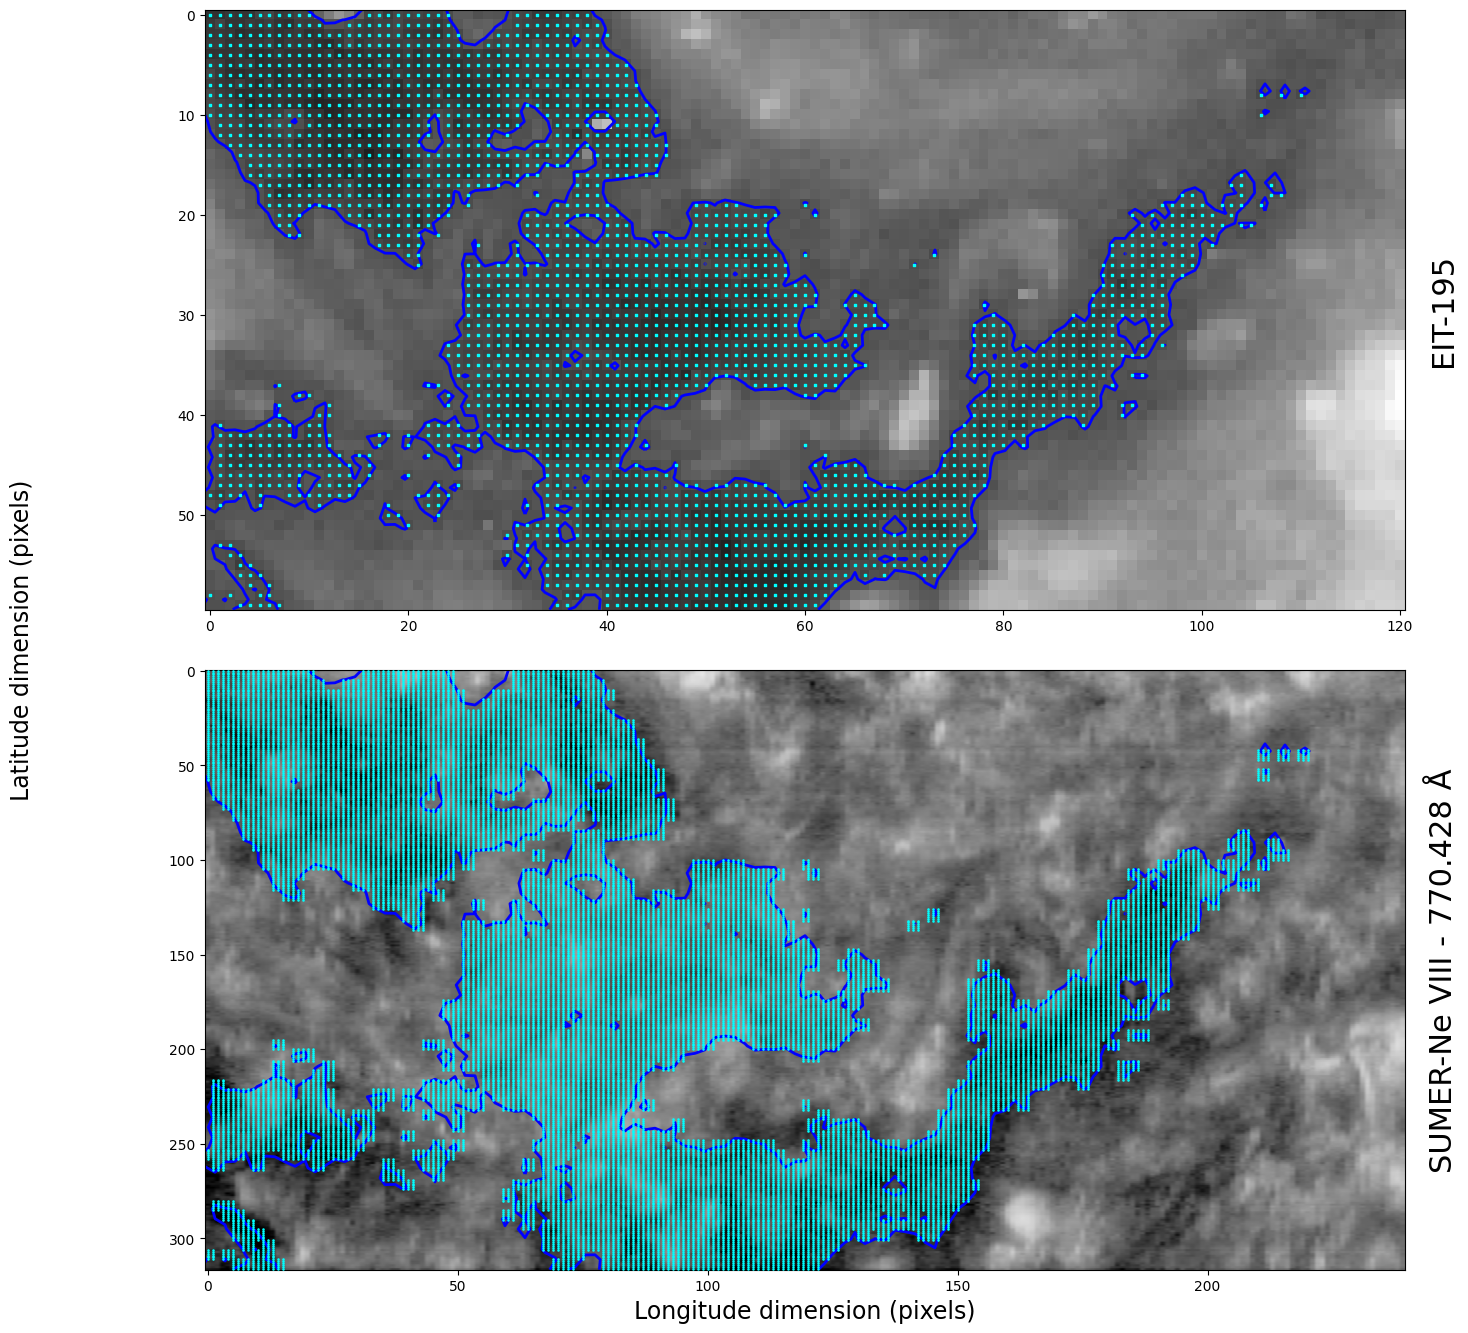

In [23]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15,14))
label_size = 18
ax[0].imshow(data_eit_crop_corrected, norm=LogNorm(vmin=vmin_eit, vmax=vmax_eit), cmap='Greys_r', aspect='auto')
ax[1].imshow(intensity_map_croplat, norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer), cmap='Greys_r', aspect='auto')
ax[1].set_aspect('auto')

ax[1].set_xlabel('Longitude dimension (pixels)', fontsize=17)
fig.supylabel('Latitude dimension (pixels)', fontsize=17)
ax[0].text(1.02, 0.5, f'EIT-{header_eit["WAVELNTH"]}', fontsize=22,transform=ax[0].transAxes, va='center', ha='left', rotation=90)
ax[1].text(1.02, 0.5, f'SUMER-{line_center_label}', fontsize=22,transform=ax[1].transAxes, va='center', ha='left', rotation=90)
plt.subplots_adjust(left=0.15, right=0.95, bottom=0.05, top=0.95, wspace=0, hspace=0.1)


# Define extents properly for EACH image
extent_eit_px = [-0.5, data_eit_crop_corrected.shape[1]-0.5, data_eit_crop_corrected.shape[0]-0.5, -0.5]
extent_sumer_px = [-0.5, intensity_map_croplat.shape[1]-0.5, intensity_map_croplat.shape[0]-0.5, -0.5]

# EIT subplot (top) - contours from EIT data
contour_lower_eit = ax[0].contour(data_eit_crop_corrected[::-1], levels=[lower_bound], colors='red', linewidths=2, extent=extent_eit_px)
contour_upper_eit = ax[0].contour(data_eit_crop_corrected[::-1], levels=[upper_bound], colors='blue', linewidths=2, extent=extent_eit_px)
# EIT subplot (bottom) - contours from EIT data
contour_lower_eit = ax[1].contour(data_eit_crop_corrected[::-1], levels=[lower_bound], colors='red', linewidths=2, extent=extent_sumer_px)
contour_upper_eit = ax[1].contour(data_eit_crop_corrected[::-1], levels=[upper_bound], colors='blue', linewidths=2, extent=extent_sumer_px)


# Scatter points - FLIP Y to match contour orientation
x_col1_list, y_row1_list_flipped = [], []
for y_row1, x_col1 in rowscols_inside_range_eit:
    x_col1_list.append(x_col1)
    #y_row1_list_flipped.append(data_eit_crop_corrected.shape[0] - 1 - y_row1)  # Flip Y
    y_row1_list_flipped.append(y_row1)  # Flip Y

x_col2_list, y_row2_list_flipped = [], []
for y_row2, x_col2 in rows_cols_sumer_from_eit:
    x_col2_list.append(x_col2)
    #y_row2_list_flipped.append(intensity_map_croplat.shape[0] - 1 - y_row2)  # Flip Y
    y_row2_list_flipped.append(y_row2)  # Flip Y

# Plot scatter AFTER contours with zorder to ensure visibility
ax[0].scatter(x_col1_list, y_row1_list_flipped, color='cyan', marker='s', s=1, zorder=10)
ax[1].scatter(x_col2_list, y_row2_list_flipped, color='cyan', marker='o', s=0.7, zorder=10)

"""
ax[0].set_xlim([x_col1-5,x_col1+5])
ax[0].set_ylim([y_row1+2,y_row1-2])
ax[1].set_xlim([100,110])
ax[1].set_ylim([y_row1*dy+10,y_row1*dy-10])
"""

plt.show(block=False)

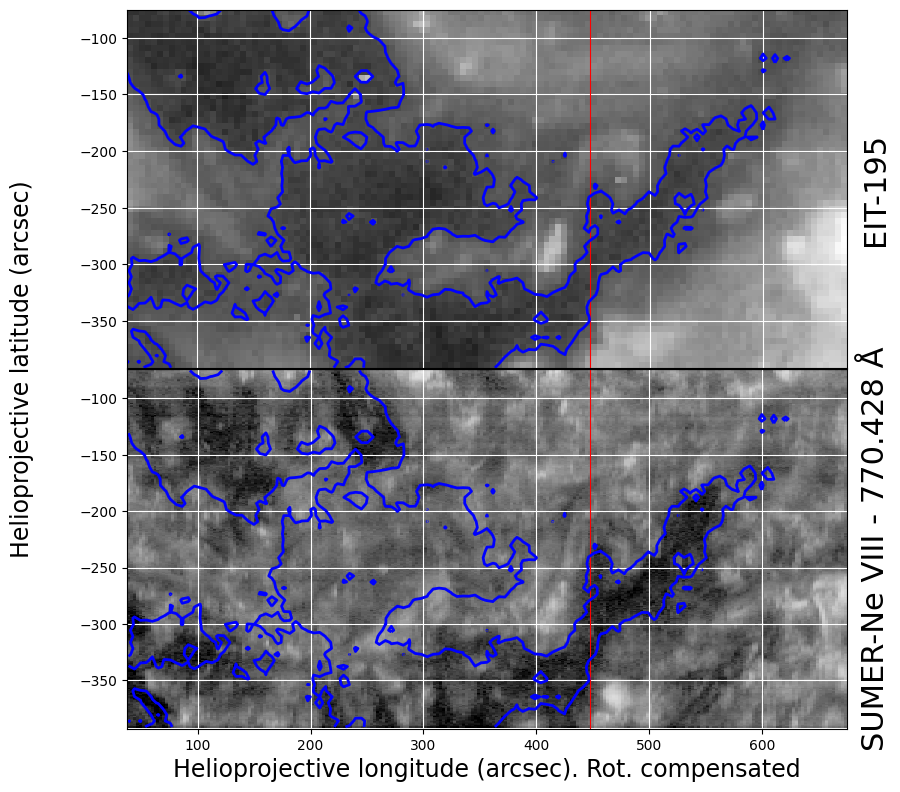

In [24]:

extent_eit_sumer = [HPlon_rotcomp[0], HPlon_rotcomp[-1], HPlat_croplat[-1], HPlat_croplat[0]]

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(9,8))
label_size = 18
ax[0].imshow(data_eit_crop_corrected, norm=LogNorm(vmin=vmin_eit, vmax=vmax_eit), cmap='Greys_r', extent=eit_extent)
ax[1].pcolormesh(HPlon_rotcomp, HPlat_croplat, intensity_map_croplat, cmap='Greys_r', norm=LogNorm(vmin=vmin_sumer, vmax=vmax_sumer))
ax[1].axis('equal') # Ensures equal scaling of axis x and y
#ax[1].set_title(f'SUMER', fontsize=22)
#ax[0].set_title(f'EIT-{header_eit["WAVELNTH"]}', fontsize=22)
ax[1].set_xlabel('Helioprojective longitude (arcsec). Rot. compensated', fontsize=17)
fig.supylabel('Helioprojective latitude (arcsec)', fontsize=17)
ax[0].text(1.02, 0.5, f'EIT-{header_eit["WAVELNTH"]}', fontsize=22,transform=ax[0].transAxes, va='center', ha='left', rotation=90)
ax[1].text(1.02, 0.5, f'SUMER-{line_center_label}', fontsize=22,transform=ax[1].transAxes, va='center', ha='left', rotation=90)
plt.subplots_adjust(left=0.15, right=0.95, bottom=0.05, top=0.95, wspace=0, hspace=0)
ax[0].grid(color='white')
ax[1].grid(color='white')
ax[0].axvline(x=HPlon_rotcomp[closest_index], linestyle='-', linewidth=0.8, color='red', label='Slit position during\n EIT image')
ax[1].axvline(x=HPlon_rotcomp[closest_index], linestyle='-', linewidth=0.8, color='red', label='Slit position during\n EIT image')
#ax[0].set_xlim([HPlon_rotcomp[0], HPlon_rotcomp[-1]])
#ax[1].set_xlim([HPlon_rotcomp[0], HPlon_rotcomp[-1]])
contour_lower = ax[0].contour(data_eit_crop_corrected[::-1], levels=[lower_bound], colors='red', linewidths=2, extent=extent_eit_sumer)
contour_upper = ax[0].contour(data_eit_crop_corrected[::-1], levels=[upper_bound], colors='blue', linewidths=2, extent=extent_eit_sumer)

legend_elements = [
    mlines.Line2D([],[],color='red', label=f'{range_percentage[0]} %'),
    mlines.Line2D([],[],color='blue', label=f'{range_percentage[1]} %')
]

contour_lower = ax[1].contour(data_eit_crop_corrected[::-1], levels=[lower_bound], colors='red', linewidths=2, extent=extent_eit_sumer)
contour_upper = ax[1].contour(data_eit_crop_corrected[::-1], levels=[upper_bound], colors='blue', linewidths=2, extent=extent_eit_sumer)

plt.show(block=False)

In [27]:
# Average spectra of the pixels selected
lam_sumer_av, elam_sumer_av, rad_sumer_av, erad_sumer_av = average_profiles_from_pixels_selected_from_interpolated_data(wavelength_range_=wavelength_range_to_average, data_interpolated_loaded_=data_interpolated_loaded, rows_cols_of_spectroheliogram=rows_cols_sumer_from_eit)

# crop near Ne VIII
lam_sumer_avNeVIII, idx_sumer_crop_ = crop_range(list_to_crop=lam_sumer_av, range_values=wavelength_range_to_analyze_NeVIII)
elam_sumer_avNeVIII = elam_sumer_av[idx_sumer_crop_[0]:idx_sumer_crop_[1]+1]
rad_sumer_avNeVIII = rad_sumer_av[idx_sumer_crop_[0]:idx_sumer_crop_[1]+1]
erad_sumer_avNeVIII = erad_sumer_av[idx_sumer_crop_[0]:idx_sumer_crop_[1]+1]

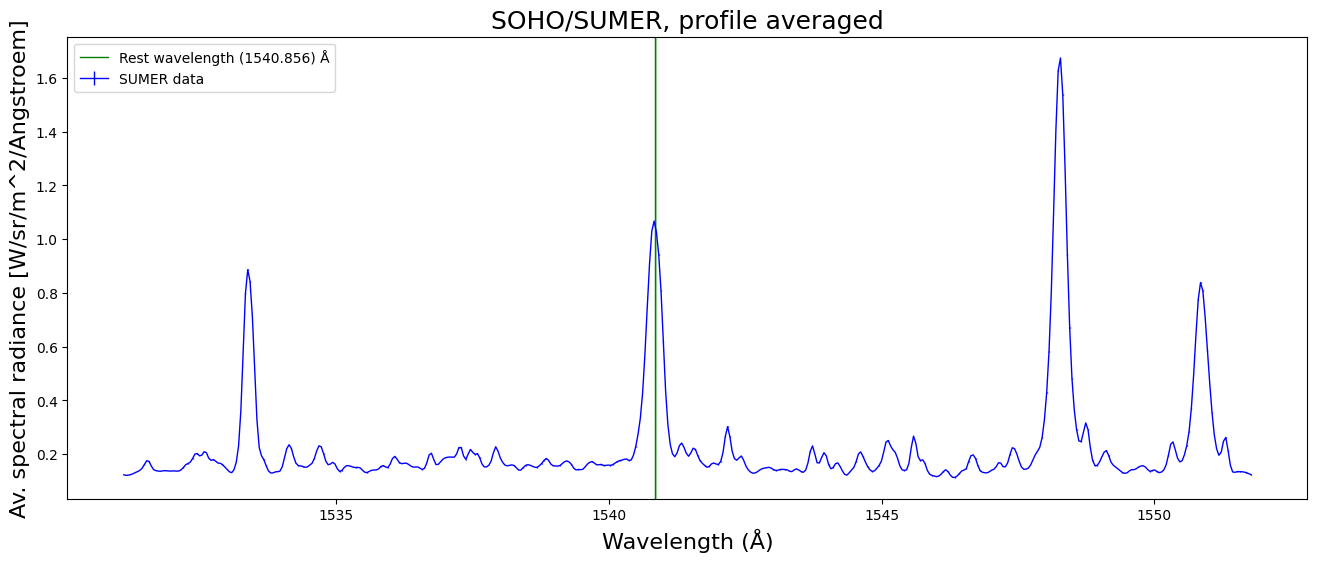

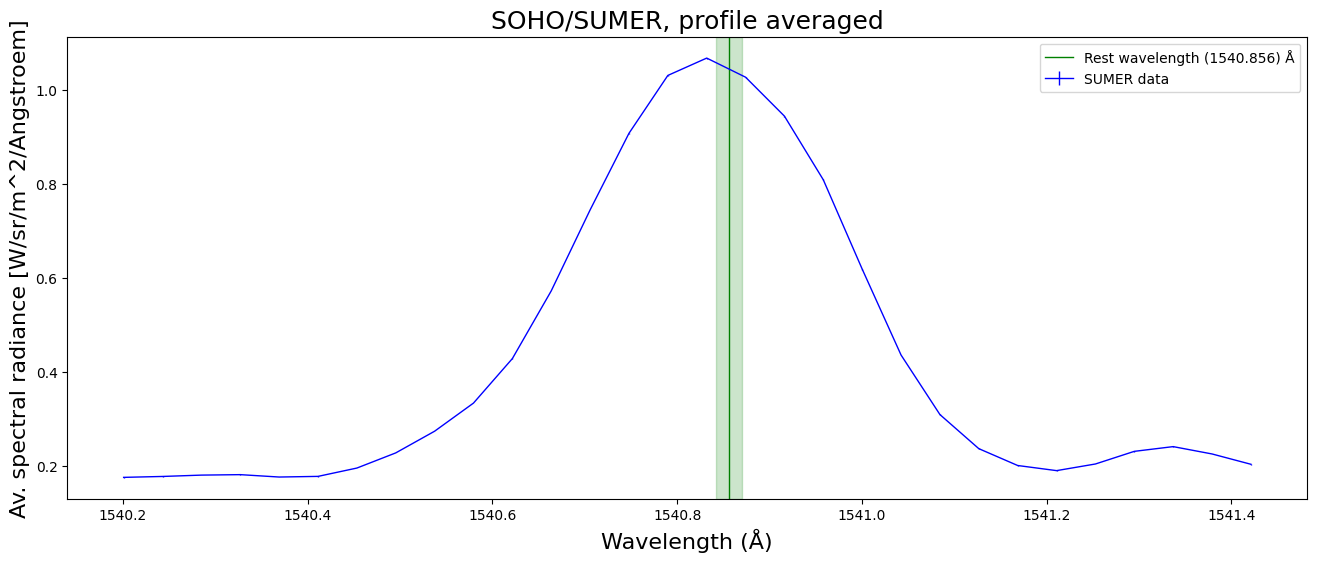

In [28]:
# Show averaged spectra
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 6))
ax.errorbar(x=lam_sumer_av, y=rad_sumer_av, yerr=erad_sumer_av, color='blue', linewidth=1., label='SUMER data')
ax.set_title(f'SOHO/SUMER, profile averaged', fontsize=18) 
ax.set_xlabel('Wavelength (\u212B)', color='black', fontsize=16)
ax.set_ylabel(f'Av. spectral radiance [W/sr/m^2/Angstroem]', color='black', fontsize=16)
ax.axvline(lam_0, color='green', linewidth=1., label=f'Rest wavelength ({lam_0})'' \u212B')
ax.axvspan(lam_0-lam_unc_0, lam_0+lam_unc_0, color='green', alpha=0.2)
ax.legend()
plt.show(block=False)


# Show averaged spectra cropped around Ne VIII
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(16, 6))
ax.errorbar(x=lam_sumer_avNeVIII, y=rad_sumer_avNeVIII, yerr=erad_sumer_avNeVIII, color='blue', linewidth=1., label='SUMER data')
ax.set_title(f'SOHO/SUMER, profile averaged', fontsize=18) 
ax.set_xlabel('Wavelength (\u212B)', color='black', fontsize=16)
ax.set_ylabel(f'Av. spectral radiance [W/sr/m^2/Angstroem]', color='black', fontsize=16)
ax.axvline(lam_0, color='green', linewidth=1., label=f'Rest wavelength ({lam_0})'' \u212B')
ax.axvspan(lam_0-lam_unc_0, lam_0+lam_unc_0, color='green', alpha=0.2)
ax.legend()
plt.show(block=False)

In [29]:
# save average profile as .npy
if save_average_profile_map == 'yes':
    range_numbers_to_string = '__'.join(f"{x:.2f}".replace('.', '_').rstrip('0') if f"{x:.2f}"[-1] != '0' else f"{x:.1f}".replace('.', '_') for x in range_percentage) 
    filename_profile = 'average_profile__' + range_numbers_to_string + '__' + threshold_value_type + '_of_eit_' + str(eit_wavelength) + '___'
    foldepath_profile = '../auxiliar_functions/'
    np.savez(foldepath_profile+filename_profile, lam_sumer_av=lam_sumer_av, rad_sumer_av=rad_sumer_av, erad_sumer_av=erad_sumer_av, lam_sumer_avNeVIII=lam_sumer_avNeVIII, rad_sumer_avNeVIII=rad_sumer_avNeVIII, erad_sumer_avNeVIII=erad_sumer_avNeVIII)


"""
In order to load the intensity map in another file (or this one), do the next:

profiles_loaded_dic = np.load(filename_profile)
lam_sumer_av = profiles_loaded_dic['lam_sumer_av'] #Angstrom
rad_sumer_av = profiles_loaded_dic['rad_sumer_av'] #[W/sr/m^2/Angstroem]
erad_sumer_av = profiles_loaded_dic['erad_sumer_av'] #[W/sr/m^2/Angstroem]
lam_sumer_avNeVIII = profiles_loaded_dic['lam_sumer_avNeVIII'] #Angstrom
rad_sumer_avNeVIII = profiles_loaded_dic['rad_sumer_avNeVIII'] #[W/sr/m^2/Angstroem]
erad_sumer_avNeVIII = profiles_loaded_dic['erad_sumer_avNeVIII'] #[W/sr/m^2/Angstroem]
"""
""


''